# Методичка

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()
X=iris.data
y=iris.target

In [ ]:
iris_data = pd.DataFrame(iris['data'], columns=iris['feature_names'])
name_map = {0: 'Iris-setosa', 1: 'Iris-versicolor', 2:'Iris-virginica'}
iris_data['class'] = [name_map[k] for k in iris['target']]
iris_data.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=5)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='liblinear')
model.fit(X_train, y_train) #Обучение трейновой выборке
y_pred = model.predict(X_test) #Предсказание для тестовой выборки
print(accuracy_score(y_test, y_pred))
print(f1_score(y_test, y_pred, average='macro'))

0.8260869565217391
0.8000000000000002


<Axes: >

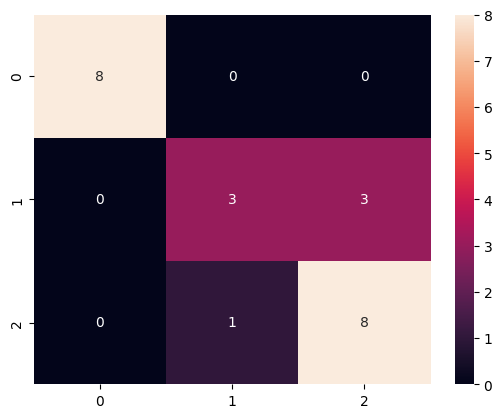

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=0)
model = LogisticRegression()
model.fit(X_train, y_train) #Обучение трейновой выборке
y_pred = model.predict(X_test) #Предсказание для тестовой выборки
print(accuracy_score(y_test, y_pred))
print(f1_score(y_test, y_pred, average='macro'))

1.0
1.0


<Axes: >

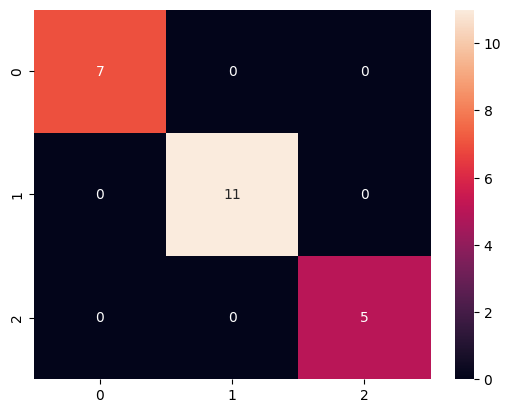

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=8)
model = LogisticRegression()
model.fit(X_train, y_train) #Обучение трейновой выборке
y_pred = model.predict(X_test) #Предсказание для тестовой выборки
print(accuracy_score(y_test, y_pred))
print(f1_score(y_test, y_pred, average='macro'))

0.8695652173913043
0.8745098039215686


<Axes: >

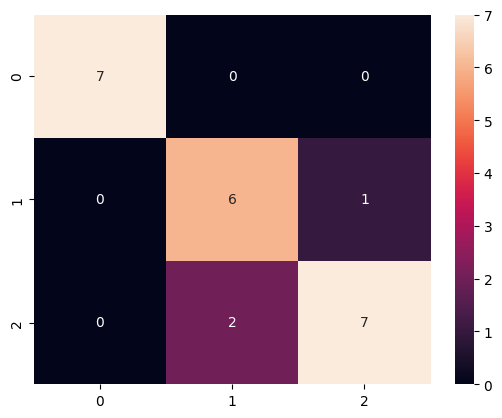

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)

## Перекрестная проверка

In [ ]:
from sklearn.model_selection import KFold,StratifiedKFold,LeaveOneOut, cross_val_score

In [ ]:
kf = KFold(n_splits = 3,shuffle=True, random_state=15)
kf

KFold(n_splits=3, random_state=15, shuffle=True)

In [ ]:
for i, (train_index, test_index) in enumerate(kf.split(y)):
    print("Fold {}: Длинна train: {}, Длинна test: {}".format(i+1, len(train_index), len(test_index)))
    print('Train: index={}\n Test:  index={}'.format(train_index, test_index))

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

Fold 1: Длинна train: 100, Длинна test: 50
Train: index=[  1   2   3   4   7  10  14  15  16  17  18  19  22  23  24  26  28  29
  32  33  34  35  37  38  39  40  41  42  43  44  45  46  49  50  51  52
  53  54  56  60  62  63  64  65  66  68  69  70  73  75  76  77  79  80
  81  82  83  85  87  88  91  92  93  94  96  99 101 102 104 105 106 107
 108 110 111 113 114 117 118 119 120 121 123 125 128 131 132 133 134 135
 136 137 139 140 141 142 144 145 146 147]
 Test:  index=[  0   5   6   8   9  11  12  13  20  21  25  27  30  31  36  47  48  55
  57  58  59  61  67  71  72  74  78  84  86  89  90  95  97  98 100 103
 109 112 115 116 122 124 126 127 129 130 138 143 148 149]
Fold 2: Длинна train: 100, Длинна test: 50
Train: index=[  0   1   4   5   6   7   8   9  10  11  12  13  15  17  19  20  21  22
  23  24  25  26  27  28  30  31  34  36  37  39  40  41  42  44  47  48
  50  53  55  56  57  58  59  60  61  62  63  65  66  67  70  71  72  74
  75  78  79  84  85  86  89  90  95  96  97

In [ ]:
metrics_accuracy = []
metrics_f1 = []
model = LogisticRegression(solver='liblinear')
for i, (train_index, test_index) in enumerate(kf.split(y)):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    metrics_accuracy.append(accuracy_score(y_test, y_pred))
    metrics_f1.append(f1_score(y_test, y_pred, average='macro'))

In [ ]:
print('Значения метрики accuracy: {} \nЗначения метрики f1: {}'.format(metrics_accuracy, metrics_f1))

Значения метрики accuracy: [0.96, 0.96, 0.9] 
Значения метрики f1: [0.9595588235294118, 0.9629629629629629, 0.890652557319224]


In [ ]:
import numpy as np
print("Среднее по кросс-валидации: ", np.array(metrics_f1).mean())

Среднее по кросс-валидации:  0.9377247812705329


In [ ]:
print("Дисперсия по кросс-валидации: ", np.array(metrics_f1).std())

Дисперсия по кросс-валидации:  0.03331408853235519


In [ ]:
cv_results = cross_val_score(model,                  # модель
                             X,                      # матрица признаков
                             y,                      # вектор цели
                             cv = kf,                # тип разбиения (можно указать просто число фолдов cv = 3)
                             scoring = 'accuracy',   # метрика
                             n_jobs=-1)              # используются все ядра CPU

print("Кросс-валидация: ", cv_results)
print("Среднее по кросс-валидации: ", cv_results.mean())
print("Дисперсия по кросс-валидации: ", cv_results.std())

Кросс-валидация:  [0.96 0.96 0.9 ]
Среднее по кросс-валидации:  0.94
Дисперсия по кросс-валидации:  0.028284271247461874


In [ ]:
skf = StratifiedKFold(n_splits=3,shuffle=True, random_state=15)
skf.get_n_splits(X, y)

3

In [ ]:
for i, (train_index, test_index) in enumerate(skf.split(X,y)):
    print(f"Fold {i+1}:")
    print('Train: index={}\n Test:  index={}'.format(train_index, test_index))

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

Fold 1:
Train: index=[  0   1   2   3   4   5   7   8   9  12  14  15  16  17  18  19  21  23
  24  25  26  28  29  31  32  36  37  38  39  40  41  44  45  51  52  53
  54  55  60  61  62  63  65  66  68  70  72  75  77  80  81  82  83  84
  85  86  87  89  90  91  93  94  95  96  97  98 101 102 103 104 105 107
 110 111 112 113 114 116 118 121 122 123 124 126 127 128 129 132 133 134
 139 140 141 142 143 144 145 146 147 149]
 Test:  index=[  6  10  11  13  20  22  27  30  33  34  35  42  43  46  47  48  49  50
  56  57  58  59  64  67  69  71  73  74  76  78  79  88  92  99 100 106
 108 109 115 117 119 120 125 130 131 135 136 137 138 148]
Fold 2:
Train: index=[  0   1   2   4   5   6   9  10  11  13  14  15  16  19  20  21  22  23
  26  27  28  29  30  31  33  34  35  42  43  46  47  48  49  50  51  54
  55  56  57  58  59  61  63  64  66  67  69  70  71  73  74  75  76  78
  79  83  84  87  88  89  90  91  92  94  96  97  99 100 101 103 105 106
 107 108 109 110 114 115 116 117 118 119 

In [ ]:
cv_results = cross_val_score(model,                  # модель
                             X,                      # матрица признаков
                             y,                      # вектор цели
                             cv = skf,           # тип разбиения
                             scoring = 'f1_macro',   # метрика
                             n_jobs=-1)              # используются все ядра CPU

print("Кросс-валидация: ", cv_results)
print("Среднее по кросс-валидации: ", cv_results.mean())

Кросс-валидация:  [1.         1.         0.92046784]
Среднее по кросс-валидации:  0.9734892787524366


In [ ]:
loo = LeaveOneOut()

In [ ]:
for i, (train_index, test_index) in enumerate(loo.split(X)):
    print(f"Fold {i+1}:")
    print('Train: index={}\n Test:  index={}'.format(train_index, test_index))

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

Fold 1:
Train: index=[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149]
 Test:  index=[0]
Fold 2:
Train: index=[  0   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  

In [ ]:
cv_results = cross_val_score(model,                  # модель
                             X,                      # матрица признаков
                             y,                      # вектор цели
                             cv = loo,           # тип разбиения
                             scoring = 'f1_macro',   # метрика
                             n_jobs=-1)              # используются все ядра CPU

print("Кросс-валидация: ", cv_results)
print("Среднее по кросс-валидации: ", cv_results.mean())

Кросс-валидация:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 0. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]
Среднее по кросс-валидации:  0.9533333333333334


# ДЗ

## 1. Изучите разбиение Leave-P-Out. Продемонстрируйте работу этого алгоритма на примере из лабораторной работы.

In [ ]:
from sklearn.model_selection import LeavePOut

In [ ]:
lpo = LeavePOut(50)

In [ ]:
for i, (train_index, test_index) in enumerate(lpo.split(X)):
    print(f"Fold {i+1}:")
    print('Train: index={}\n Test:  index={}'.format(train_index, test_index))

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

Выходные данные были обрезаны до нескольких последних строк (5000).
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 120 121 122 123 124 125 126
 127 128 129 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145
 146 147 148 149]
 Test:  index=[119 130]
Fold 10722:
Train: index=[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 120 121 122 123 124 125 126
 127 128 129 130 132 133 134 135 136 137 138 139 140 141 142 1

In [ ]:
cv_results = cross_val_score(model,                  # модель
                             X,                      # матрица признаков
                             y,                      # вектор цели
                             cv = lpo,           # тип разбиения
                             scoring = 'f1_macro',   # метрика
                             n_jobs=-1)              # используются все ядра CPU

print("Кросс-валидация: ", cv_results)
print("Среднее по кросс-валидации: ", cv_results.mean())

Кросс-валидация:  [1. 1. 1. ... 1. 1. 1.]
Среднее по кросс-валидации:  0.9405219985085758


## 2. Изучите функцию cross_validate(). Продемонстрируйте работу этой функции на тех же данных.

In [ ]:
from sklearn.model_selection import cross_validate

In [ ]:
scores = cross_validate(model, X, y, cv=lpo,
                        scoring=('accuracy', 'f1_macro'),
                        return_train_score=True,
                       n_jobs=-1)
print(f'Среднее fit_time: {scores["fit_time"].mean()}')
print(f'Среднее score_time: {scores["score_time"].mean()}')
print(f'Среднее test_accuracy: {scores["test_accuracy"].mean()}')
print(f'Среднее train_accuracy: {scores["train_accuracy"].mean()}')
print(f'Среднее test_f1_macro: {scores["test_f1_macro"].mean()}')
print(f'Среднее train_f1_macro: {scores["train_f1_macro"].mean()}')

Среднее fit_time: 0.003187955113865385
Среднее score_time: 0.006699188091610902
Среднее test_accuracy: 0.9550335570469799
Среднее train_accuracy: 0.962482616845033
Среднее test_f1_macro: 0.9405219985085758
Среднее train_f1_macro: 0.9624244114783046


## 3. Оцените при помощи кросс-валидации другие метрики эффективности для этой же модели.

In [ ]:
scores = cross_validate(model, X, y, cv=lpo,
                        scoring=('precision_macro','recall_macro', 'roc_auc_ovr', 'balanced_accuracy'),
                        return_train_score=True,
                        n_jobs=-1)
scores

{'fit_time': array([0.00225139, 0.0023098 , 0.00215507, ..., 0.00219893, 0.00228691,
        0.00221825]),
 'score_time': array([0.01328158, 0.01806712, 0.01030993, ..., 0.01078534, 0.01248765,
        0.01109862]),
 'test_precision_macro': array([1., 1., 1., ..., 1., 1., 1.]),
 'train_precision_macro': array([0.96188943, 0.96188943, 0.96775057, ..., 0.96676401, 0.96676401,
        0.96676401]),
 'test_recall_macro': array([1., 1., 1., ..., 1., 1., 1.]),
 'train_recall_macro': array([0.96      , 0.96      , 0.96666667, ..., 0.96638889, 0.96638889,
        0.96638889]),
 'test_roc_auc_ovr': array([nan, nan, nan, ..., nan, nan, nan]),
 'train_roc_auc_ovr': array([0.99122449, 0.99129252, 0.99129252, ..., 0.99175595, 0.99203231,
        0.99196287]),
 'test_balanced_accuracy': array([1., 1., 1., ..., 1., 1., 1.]),
 'train_balanced_accuracy': array([0.96      , 0.96      , 0.96666667, ..., 0.96638889, 0.96638889,
        0.96638889])}

In [ ]:
print(f'Среднее fit_time: {scores["fit_time"].mean()}')
print(f'Среднее score_time: {scores["score_time"].mean()}')
print(f'Среднее test_precision_macro: {scores["test_precision_macro"].mean()}')
print(f'Среднее test_recall_macro: {scores["test_recall_macro"].mean()}')
print(f'Среднее test_roc_auc_ovr: {scores["test_roc_auc_ovr"].mean()}')
print(f'Среднее test_balanced_accuracy: {scores["test_balanced_accuracy"].mean()}')

Среднее fit_time: 0.003450021530424455
Среднее score_time: 0.01759011654779148
Среднее test_precision_macro: 0.9430574198359435
Среднее test_recall_macro: 0.9426323639075318
Среднее test_roc_auc_ovr: nan
Среднее test_balanced_accuracy: 0.9550335570469799


## 4. Сравните кросс-валидированные результаты работы нескольких моделей на одних и тех же данных.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
models = {"Логистическая регрессия": LogisticRegression(),
    "Дерево решений": DecisionTreeClassifier(),
    "Случайный лес": RandomForestClassifier(),
    "Метод опорных векторов (без ядра)": SVC(),
    "Метод опорных векторов (с линейным ядром)": SVC(kernel='linear'),
    "Метод опорных векторов (с гауссовым ядром)": SVC(kernel='rbf'),
    "Метод опорных векторов (с полиномиальным ядром)": SVC(kernel='poly'),
    "Метод К ближайших соседей": KNeighborsClassifier(),
    "Наивный байесовский метод": GaussianNB(),
    "Многослойный перцептрон": MLPClassifier()
}

In [ ]:
kf = KFold(n_splits = 3,shuffle=True, random_state=15)
kf

NameError: name 'KFold' is not defined

In [ ]:
results = {}

for name, model in models.items():
    scores = cross_validate(model, X, y, cv=kf, scoring=('accuracy', 'f1_macro'),
                        return_train_score=True,
                        n_jobs=-1)
    results[name] = scores

print("Cross-Validation Accuracy")
for name, scores in results.items():
    print(f"{name}: {scores['test_accuracy'].mean()}")

print("Cross-Validation F1_macro")
for name, scores in results.items():
    print(f"{name}: {scores['test_f1_macro'].mean()}")

print("\nFit time")
for name, scores in results.items():
    print(f"{name}: {scores['fit_time'].mean()}")

print("\nScore time")
for name, scores in results.items():
    print(f"{name}: {scores['score_time'].mean()}")

Cross-Validation Accuracy
Логистическая регрессия: 0.96
Дерево решений: 0.9133333333333334
Случайный лес: 0.94
Метод опорных векторов (без ядра): 0.9533333333333333
Метод опорных векторов (с линейным ядром): 0.9866666666666667
Метод опорных векторов (с гауссовым ядром): 0.9533333333333333
Метод опорных векторов (с полиномиальным ядром): 0.9466666666666667
Метод К ближайших соседей: 0.94
Наивный байесовский метод: 0.9466666666666667
Многослойный перцептрон: 0.9733333333333333
Cross-Validation F1_macro
Логистическая регрессия: 0.9598719184926082
Дерево решений: 0.9127343316122903
Случайный лес: 0.9391832308498974
Метод опорных векторов (без ядра): 0.953414478904675
Метод опорных векторов (с линейным ядром): 0.9865325643103421
Метод опорных векторов (с гауссовым ядром): 0.953414478904675
Метод опорных векторов (с полиномиальным ядром): 0.9463915263357454
Метод К ближайших соседей: 0.9405596886305299
Наивный байесовский метод: 0.9454750765095592
Многослойный перцептрон: 0.9736304847415959


In [ ]:
skf = StratifiedKFold(n_splits=3,shuffle=True, random_state=15)
skf.get_n_splits(X, y)

3

In [ ]:
results = {}

for name, model in models.items():
    scores = cross_validate(model, X, y, cv=skf, scoring=('accuracy', 'f1_macro'),
                        return_train_score=True,
                        n_jobs=-1)
    results[name] = scores

print("Cross-Validation Accuracy")
for name, scores in results.items():
    print(f"{name}: {scores['test_accuracy'].mean()}")

print("Cross-Validation F1_macro")
for name, scores in results.items():
    print(f"{name}: {scores['test_f1_macro'].mean()}")

print("\nFit time")
for name, scores in results.items():
    print(f"{name}: {scores['fit_time'].mean()}")

print("\nScore time")
for name, scores in results.items():
    print(f"{name}: {scores['score_time'].mean()}")

Cross-Validation Accuracy
Логистическая регрессия: 0.96
Дерево решений: 0.9533333333333333
Случайный лес: 0.96
Метод опорных векторов (без ядра): 0.96
Метод опорных векторов (с линейным ядром): 0.9733333333333333
Метод опорных векторов (с гауссовым ядром): 0.96
Метод опорных векторов (с полиномиальным ядром): 0.96
Метод К ближайших соседей: 0.9466666666666667
Наивный байесовский метод: 0.9533333333333333
Многослойный перцептрон: 0.9666666666666667
Cross-Validation F1_macro
Логистическая регрессия: 0.9598220769789397
Дерево решений: 0.9528990620099478
Случайный лес: 0.960036100896316
Метод опорных векторов (без ядра): 0.9598473857882461
Метод опорных векторов (с линейным ядром): 0.9733650509188144
Метод опорных векторов (с гауссовым ядром): 0.9598473857882461
Метод опорных векторов (с полиномиальным ядром): 0.9598992233400835
Метод К ближайших соседей: 0.9463815582095152
Наивный байесовский метод: 0.9535171296714623
Многослойный перцептрон: 0.9667304461871525

Fit time
Логистическая рег

Если приоритетом является максимальная точность и F1-мера, то "Метод опорных векторов (с линейным ядром)" является лучшим выбором. Он показывает наивысшие результаты по обеим метрикам.Если важна скорость обучения и оценки, то "Дерево решений" и "Логистическая регрессия" могут быть предпочтительнее, хотя они показывают несколько меньшую точность.

##5. Повторите анализ на другом датасете: встроенном наборе данных о диабет

In [ ]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

In [ ]:
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [ ]:
y

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59., 104., 182.,
       128.,  52.,  37., 170., 170.,  61., 144.,  52., 128.,  71., 163.,
       150.,  97., 160., 178.,  48., 270., 202., 111.,  85.,  42., 170.,
       200., 252., 113., 143.,  51.,  52., 210.,  65., 141.,  55., 134.,
        42., 111.,  98., 164.,  48.,  96.,  90., 162., 150., 279.,  92.,
        83., 128., 102., 302., 198.,  95.,  53., 134., 144., 232.,  81.,
       104.,  59., 246., 297., 258., 229., 275., 281., 179., 200., 200.,
       173., 180.,  84., 121., 161.,  99., 109., 115., 268., 274., 158.,
       107.,  83., 103., 272.,  85., 280., 336., 281., 118., 317., 235.,
        60., 174., 259., 178., 128.,  96., 126., 28

In [ ]:
X.shape, y.shape

((442, 10), (442,))

Целевая переменная в load_diabetes - это количественный показатель прогрессирования заболевания.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

models = {"Линейная регрессия": LinearRegression(),
    "Дерево решений": DecisionTreeRegressor(),
    "Случайный лес": RandomForestRegressor(),
    "Метод опорных векторов": SVR(),
    "Метод К ближайших соседей": KNeighborsRegressor(),
    "Многослойный перцептрон": MLPRegressor()}


In [ ]:
results = {}

for name, model in models.items():
    scores = cross_validate(model, X, y, cv=kf, scoring=('r2', 'neg_mean_squared_error'),
                        return_train_score=True,
                        n_jobs=-1)
    results[name] = scores

print("Cross-Validation R^2")
for name, scores in results.items():
    print(f"{name}: {scores['test_r2'].mean()}")

print("Cross-Validation MSE")
for name, scores in results.items():
    print(f"{name}: {scores['test_neg_mean_squared_error'].mean()}")

print("\nFit time")
for name, scores in results.items():
    print(f"{name}: {scores['fit_time'].mean()}")

print("\nScore time")
for name, scores in results.items():
    print(f"{name}: {scores['score_time'].mean()}")

Cross-Validation R^2
Линейная регрессия: 0.4815153690504264
Дерево решений: -0.10308761644242119
Случайный лес: 0.42318724371917366
Метод опорных векторов: 0.140921805285685
Метод К ближайших соседей: 0.3819627516470261
Многослойный перцептрон: -3.0361827296374955
Cross-Validation MSE
Линейная регрессия: -3071.9839401919685
Дерево решений: -6539.822041429184
Случайный лес: -3418.8644726542866
Метод опорных векторов: -5093.024007332789
Метод К ближайших соседей: -3660.8606453392167
Многослойный перцептрон: -23899.731754437536

Fit time
Линейная регрессия: 0.0019455750783284504
Дерево решений: 0.004883607228597005
Случайный лес: 0.6827152570088705
Метод опорных векторов: 0.014790534973144531
Метод К ближайших соседей: 0.0015471776326497395
Многослойный перцептрон: 0.48512037595113117

Score time
Линейная регрессия: 0.002130428949991862
Дерево решений: 0.005602280298868815
Случайный лес: 0.04133447011311849
Метод опорных векторов: 0.013001283009847006
Метод К ближайших соседей: 0.00768653

In [ ]:
results = {}

for name, model in models.items():
    scores = cross_validate(model, X, y, cv=skf, scoring=('r2', 'neg_mean_squared_error'),
                        return_train_score=True,
                        n_jobs=-1)
    results[name] = scores

print("Cross-Validation R^2")
for name, scores in results.items():
    print(f"{name}: {scores['test_r2'].mean()}")

print("Cross-Validation MSE")
for name, scores in results.items():
    print(f"{name}: {scores['test_neg_mean_squared_error'].mean()}")

print("\nFit time")
for name, scores in results.items():
    print(f"{name}: {scores['fit_time'].mean()}")

print("\nScore time")
for name, scores in results.items():
    print(f"{name}: {scores['score_time'].mean()}")

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklea

Cross-Validation R^2
Линейная регрессия: 0.4628337527525974
Дерево решений: -0.15243411554423192
Случайный лес: 0.4406655108947091
Метод опорных векторов: 0.1395107082415825
Метод К ближайших соседей: 0.359108350769269
Многослойный перцептрон: -3.0092241651785905
Cross-Validation MSE
Линейная регрессия: -3173.702482184083
Дерево решений: -6819.2544278972855
Случайный лес: -3310.1734049365696
Метод опорных векторов: -5102.585231860979
Метод К ближайших соседей: -3801.9840736655024
Многослойный перцептрон: -23754.793808590275

Fit time
Линейная регрессия: 0.005113522211710612
Дерево решений: 0.010203282038370768
Случайный лес: 0.8047662576039633
Метод опорных векторов: 0.017386992772420246
Метод К ближайших соседей: 0.0019257863362630208
Многослойный перцептрон: 0.5884072780609131

Score time
Линейная регрессия: 0.002670447031656901
Дерево решений: 0.006606896718343099
Случайный лес: 0.03371532758076986
Метод опорных векторов: 0.008063395818074545
Метод К ближайших соседей: 0.01327753067

## 6. Сделайте k-блочную перекрёстную проверку (KFold) модели логистической регрессии, предварительно стандартизировав данные. Для этого создайте конвейер с помощью make_pipeline из библиотеки sklearn.pipeline, который будет стандартизировать, а затем выполнять логистическую регрессию.

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [ ]:
pipeline = make_pipeline(StandardScaler(), LinearRegression())
pipeline

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearregression', LinearRegression())])

In [ ]:
scores = cross_validate(pipeline,X, y, cv=kf, scoring=('r2', 'neg_mean_squared_error'),
                        return_train_score=True,
                        n_jobs=-1)
scores

{'fit_time': array([0.0057478 , 0.00717688, 0.0042522 ]),
 'score_time': array([0.01522422, 0.02460074, 0.00405765]),
 'test_r2': array([0.48035406, 0.48729313, 0.47689891]),
 'train_r2': array([0.5196346 , 0.52723183, 0.52683717]),
 'test_neg_mean_squared_error': array([-2905.30105139, -3167.12591111, -3143.52485808]),
 'train_neg_mean_squared_error': array([-2930.47743166, -2742.68037518, -2784.4808035 ])}

In [ ]:
print(f'Среднее fit_time: {scores["fit_time"].mean()}')
print(f'Среднее score_time: {scores["score_time"].mean()}')
print(f'Среднее test_r2: {scores["test_r2"].mean()}')
print(f'Среднее test_neg_mean_squared_error: {scores["test_neg_mean_squared_error"].mean()}')

Среднее fit_time: 0.0057256221771240234
Среднее score_time: 0.014627536137898764
Среднее test_r2: 0.4815153690504264
Среднее test_neg_mean_squared_error: -3071.9839401919685
